# MSc Project nnUNet

In [ ]:
!pip install -q nibabel

In [ ]:
!pip install SimpleITK batchgenerators nnunetv2

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.7 MB/s eta 0:00:00
  Created wheel for acvl-utils: filename=acvl_utils-0.2.6-py3-none-any.whl siz

In [ ]:
import os
import torch
import shutil
import tempfile
import random
import kagglehub
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from google.colab import files, output
import numpy as np
print(torch.cuda.is_available())

False


In [ ]:
#............................................
os.environ["nnUNet_raw"] = "/content/nnUNet/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/nnUNet/nnUNet_results"

!mkdir -p /content/nnUNet/nnUNet_raw
!mkdir -p /content/nnUNet/nnUNet_preprocessed
!mkdir -p /content/nnUNet/nnUNet_results
#..............................................
from nnunetv2.paths import nnUNet_raw
from batchgenerators.utilities.file_and_folder_operations import *
from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json

## Initial Dataset Loading & Setup

### Downloading dataset from kaggle

In [ ]:
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
print("Path to dataset files:", path)
print("Exists:", os.path.exists(path))
print("Contents:", os.listdir(path))

100%|██████████| 4.16G/4.16G [02:00<00:00, 37.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/versions/1
Exists: True
Contents: ['BraTS2020_TrainingData', 'BraTS2020_ValidationData']


### File Format Check

In [ ]:
print("Opening both Folders")
train_dir = os.path.join(path, "BraTS2020_TrainingData")
val_dir = os.path.join(path, "BraTS2020_ValidationData")

train_folder = os.listdir(train_dir)
val_folder = os.listdir(val_dir)

print("BraTS2020_TrainingData:", train_folder)
print("BraTS2020_ValidationData:", val_folder)

Opening both Folders
BraTS2020_TrainingData: ['MICCAI_BraTS2020_TrainingData']
BraTS2020_ValidationData: ['MICCAI_BraTS2020_ValidationData']


### File Content

In [ ]:
train_dir = os.path.join(path,"BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")
train_subjects = sorted(os.listdir(train_dir))
# USE GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Total files in MICCAI_BraTS2020_TrainingData:", len(train_subjects))
# Pick one subject
train_subject = train_subjects[0]
train_subject_path = os.path.join(train_dir, train_subject)
files_train = os.listdir(train_subject_path)
print("Training data subject file content:", files_train)

Using device: cpu
Total files in MICCAI_BraTS2020_TrainingData: 371
Training data subject file content: ['BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t2.nii']


BraTS subjects occasionally contain missing or corrupted files.  
The `check_valid()` function ensures each subject contains all required modalities and a segmentation mask.

In [ ]:
def check_valid(Base_dir, subject_id):
  filepath = os.path.join(Base_dir, subject_id)
  if not os.path.isdir(filepath):
    return False

  required_files = [
      f"{subject_id}_t1.nii",
      f"{subject_id}_t1ce.nii",
      f"{subject_id}_t2.nii",
      f"{subject_id}_flair.nii",
      f"{subject_id}_seg.nii"]

  for f in required_files:
    if not os.path.exists(os.path.join(filepath, f)):
      print(f"Warning: Missing file {f} for subject {subject_id}. Excluding subject.")
      return False
  return True

To reduce training time on Colab, we randomly select 100 valid subjects from the full BraTS2020 training set.

In [ ]:
def BraTSDataset(data_dir, seed=42, size=100):
    subjects = [
    s for s in sorted(os.listdir(data_dir))
    if check_valid(data_dir, s)
    ]
    print("Total valid training data subjects:", len(subjects))
    data_list = subjects
    random.Random(seed).shuffle(data_list)
    selected = data_list[:size]
    print("Total selected subjects:", len(selected))
    return selected

## Converting BraTS Labels to nnU-Net Format

In [ ]:
def convert_brats_labels_to_nnunet(in_file, out_file):
    img = sitk.ReadImage(in_file)
    arr = sitk.GetArrayFromImage(img)

    uniques = np.unique(arr)
    for u in uniques:
        if u not in [0, 1, 2, 4]:
            raise RuntimeError(f"Unexpected label {u}")

    new = np.zeros_like(arr)
    new[arr == 4] = 3
    new[arr == 2] = 1
    new[arr == 1] = 2

    out = sitk.GetImageFromArray(new)
    out.CopyInformation(img)
    sitk.WriteImage(out, out_file)

In [ ]:
task_id = 501
task_name = "BraTS2020"
foldername = f"Dataset{task_id:03d}_{task_name}"

out_base = os.path.join(nnUNet_raw, foldername)
imagesTr = os.path.join(out_base, "imagesTr")
labelsTr = os.path.join(out_base, "labelsTr")

maybe_mkdir_p(imagesTr)
maybe_mkdir_p(labelsTr)

In [ ]:
selected_set = BraTSDataset(train_dir, seed=42, size=100)
for case in selected_set:
  # Correctly construct subject_path including the 'MICCAI_BraTS2020_TrainingData' subdirectory
  subject_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData", case)
  # Copy modalities
  shutil.copy(join(subject_path, f"{case}_t1.nii"),   join(imagesTr, f"{case}_0000.nii.gz"))
  shutil.copy(join(subject_path, f"{case}_t1ce.nii"), join(imagesTr, f"{case}_0001.nii.gz"))
  shutil.copy(join(subject_path, f"{case}_t2.nii"),   join(imagesTr, f"{case}_0002.nii.gz"))
  shutil.copy(join(subject_path, f"{case}_flair.nii"),join(imagesTr, f"{case}_0003.nii.gz"))

  # Convert segmentation labels
  convert_brats_labels_to_nnunet(
      join(subject_path, f"{case}_seg.nii"),
      join(labelsTr, f"{case}.nii.gz")
  )
print("Copied all files to", out_base)
print("converted labels from 4 to 3, 2 to 1 and 1 to 2")

Total valid training data subjects: 368
Total selected subjects: 100
Copied all files to /content/nnUNet/nnUNet_raw/Dataset501_BraTS2020
converted labels from 4 to 3, 2 to 1 and 1 to 2


In [ ]:
imgs = sorted(os.listdir(imagesTr))
segs = sorted(os.listdir(labelsTr))

print(len(imgs), "image files (expected 4 x #cases)")
print(len(segs), "label files (expected #cases)")
assert len(segs) == len(selected_set)
assert len(imgs) == 4 * len(selected_set)

400 image files (expected 4 x #cases)
100 label files (expected #cases)


## Generating nnU-Net Dataset JSON
The dataset JSON describes:
- Input modalities  
- Label definitions  
- Number of training cases  
- File naming conventions

In [ ]:
generate_dataset_json(
    out_base,
    channel_names={0: "T1", 1: "T1ce", 2: "T2", 3: "FLAIR"},
    labels={
        "background": 0,
        "whole tumor": (1, 2, 3),
        "tumor core": (2, 3),
        "enhancing tumor": (3,)
    },
    num_training_cases=len(selected_set),
    file_ending=".nii.gz",
    regions_class_order=(1, 2, 3),
    license="BraTS 2020 License",
    reference="https://www.med.upenn.edu/cbica/brats2020/",
    dataset_release="1.0"
)

## Extracting Dataset Fingerprint

In [ ]:
!nnUNetv2_extract_fingerprint -d 501

Dataset501_BraTS2020
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 100/100 [00:17<00:00,  5.65it/s]


## Planning the Experiment
The planner (`nnUNetPlannerResEncL`) determines:
- Patch size  
- Batch size  
- Network depth  
- Resampling strategy  

We target 16 GB GPU memory

In [ ]:
!nnUNetv2_plan_experiment -d 501 -pl nnUNetPlannerResEncL -gpu_memory_target 16 -overwrite_plans_name nnUNetResEncL_Colab

/usr/local/lib/python3.13/dist-packages/nnunetv2/experiment_planning/experiment_planners/residual_unets/residual_encoder_unet_planners.py:256: UserWarning: WARNING: You are running nnUNetPlannerL with a non-standard gpu_memory_target_in_gb. Expected 24, got 16.0.You should only see this warning if you modified this value intentionally!!
  warnings.warn("WARNING: You are running nnUNetPlannerL with a non-standard gpu_memory_target_in_gb. "
Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [139. 169. 138.], 3d_lowres: [139, 169, 138]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 201, 'patch_size': (np.int64(192), np.int64(160)), 'median_image_size_in_voxels': array([169., 138.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [True, True, True, Tr

## Preprocessing

nnU-Net performs:
- Resampling  
- Cropping  
- Normalisation  
- Foreground extraction  

The output is stored in `nnUNet_preprocessed/`.

In [ ]:
!nnUNetv2_preprocess -d 501 -c 3d_fullres -p nnUNetResEncL_Colab

Preprocessing dataset Dataset501_BraTS2020
Configuration: 3d_fullres...
{'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [160, 192, 160], 'median_image_size_in_voxels': [139.0, 169.0, 138.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [True, True, True, True], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_archit

## Training nnU-Net (3D Full Resolution)

We train two folds (0 and 1) using the `nnUNetTrainer_50epochs` trainer.  
Each fold trains a separate model on a different split of the dataset.

In [ ]:
!CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 501 3d_fullres 0 -p nnUNetResEncL_Colab -device cuda -tr nnUNetTrainer_50epochs

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-01 08:52:01.512197: Using torch.compile...
2026-09-01 08:52:04.594265: do_dummy_2d_data_aug: False
2026-09-01 08:52:04.595472: Creating new 5-fold cross-validation split...
2026-09-01 08:52:04.597205: Desired fold for training: 0
2026-09-01 08:52:04.597358: This split has 80 training and 20 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size

In [ ]:
!CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 501 3d_fullres 1 -p nnUNetResEncL_Colab -device cuda -tr nnUNetTrainer_50epochs

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-01 10:56:40.638280: Using torch.compile...
2026-09-01 10:56:41.839592: do_dummy_2d_data_aug: False
2026-09-01 10:56:41.840683: Using splits from existing split file: /content/nnUNet/nnUNet_preprocessed/Dataset501_BraTS2020/splits_final.json
2026-09-01 10:56:41.841027: The split file contains 5 splits.
2026-09-01 10:56:41.841148: Desired fold for training: 1
2026-09-01 10:56:41.841238: This split has 80 training and 20 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 

## Selecting Best Configuration

nnU-Net evaluates cross‑validation results from folds 0 and 1 and selects the best-performing configuration for inference.


In [ ]:
os.environ["nnUNet_raw"] = "/content/nnUNet/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/nnUNet/nnUNet_results"

!nnUNetv2_find_best_configuration 501 -c 3d_fullres -tr nnUNetTrainer_50epochs -p nnUNetResEncL_Colab -f 0 1


***All results:***
nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres: 0.8110263262377223

*Best*: nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres: 0.8110263262377223

***Determining postprocessing for best model/ensemble***
Removing all but the largest foreground region did not improve results!
Removing all but the largest component for (1, 2, 3) did not improve results! Dice before: 0.8989 after: 0.89739
Removing all but the largest component for (2, 3) did not improve results! Dice before: 0.83715 after: 0.82613
Removing all but the largest component for (3,) did not improve results! Dice before: 0.69703 after: 0.67892

***Run inference like this:***

nnUNetv2_predict -d Dataset501_BraTS2020 -i INPUT_FOLDER -o OUTPUT_FOLDER -f  0 1 -tr nnUNetTrainer_50epochs -c 3d_fullres -p nnUNetResEncL_Colab

***Once inference is completed, run postprocessing like this:***

nnUNetv2_apply_postprocessing -i OUTPUT_FOLDER -o OUTPUT_FOLDER_PP -pp_pkl_file /content/nnUNet/nnUNet_results

## Running Predictions

We run inference on the training images to generate segmentation masks.

Post‑processing removes small false‑positive components using the automatically generated `postprocessing.pkl`.

In [ ]:
!nnUNetv2_predict -d Dataset501_BraTS2020 -i /content/nnUNet/nnUNet_raw/Dataset501_BraTS2020/imagesTr -o /content/nnUNet/nnUNet_results/predictions -f 0 1 -tr nnUNetTrainer_50epochs -c 3d_fullres -p nnUNetResEncL_Colab -device cuda


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 100 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 100 cases that I would like to predict

Predicting BraTS20_Training_011:
perform_everything_on_device: True
100% 1/1 [00:16<00:00, 16.67s/it]
100% 1/1 [00:00<00:00,  2.14it/s]
sending off prediction to background worker for resampling and export
done with BraTS20_Training_011

Predicting BraTS20_Training_012:
perform_everything_on_device: True
100% 1/1 [00:00<00:00,  2.13it/s]
100% 1/1 [00:00<00:00,  2.14it/s]
sending off prediction to background worker for resampling 

In [ ]:
!nnUNetv2_apply_postprocessing -i /content/nnUNet/nnUNet_results/predictions -o /content/nnUNet/nnUNet_results/predictions_pp -pp_pkl_file /content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/crossval_results_folds_0_1/postprocessing.pkl -np 8 -plans_json /content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/crossval_results_folds_0_1/plans.json

## Evaluating Predictions
We compare predicted masks against ground truth using nnU-Net’s evaluation

In [ ]:
!nnUNetv2_evaluate_folder /content/nnUNet/nnUNet_raw/Dataset501_BraTS2020/labelsTr /content/nnUNet/nnUNet_results/predictions -djfile /content/nnUNet/nnUNet_raw/Dataset501_BraTS2020/dataset.json -pfile /content/nnUNet/nnUNet_preprocessed/Dataset501_BraTS2020/nnUNetResEncL_Colab.json

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


In [ ]:
# 1. Zip the predictions folder
!zip -r nnunet_results.zip /content/nnUNet/nnUNet_results

  adding: content/nnUNet/nnUNet_results/ (stored 0%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/ (stored 0%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/inference_instructions.txt (deflated 57%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/ (stored 0%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/crossval_results_folds_0_1/ (stored 0%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/crossval_results_folds_0_1/BraTS20_Training_134.nii.gz (deflated 33%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_fullres/crossval_results_folds_0_1/BraTS20_Training_054.nii.gz (deflated 32%)
  adding: content/nnUNet/nnUNet_results/Dataset501_BraTS2020/nnUNetTrainer_50epochs__nnUNetResEncL_Colab__3d_

In [ ]:
files.download('/content/nnunet_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualising Segmentation Results

We load:
- FLAIR modality  
- Ground truth segmentation  
- nnU-Net prediction  

A representative centre slice is selected where tumour tissue is present.  
We overlay segmentation masks using a custom colour map to highlight:
- Necrotic/non‑enhancing tumour  
- Edema  
- Enhancing tumour  

In [ ]:
case = "BraTS20_Training_100"
flair_path = Path(f"/content/nnUNet/nnUNet_raw/Dataset501_BraTS2020/imagesTr/{case}_0003.nii.gz")
ground_truth_path = Path(f"/content/nnUNet/nnUNet_raw/Dataset501_BraTS2020/labelsTr/{case}.nii.gz")
prediction_path = Path(f"/content/drive/MyDrive/brats_project/nnunet_results/predictions_pp/{case}.nii.gz")

In [ ]:
def load(path):
    with open(path, "rb") as file:
        is_gzip = file.read(2) == b"\x1f\x8b"
    if not is_gzip:
        temporary = Path(tempfile.gettempdir()) / f"{path.name}.nii"
        shutil.copyfile(path, temporary)
        path = temporary
    return np.asanyarray(nib.load(str(path)).dataobj)

In [ ]:
flair = load(flair_path)
ground_truth = load(ground_truth_path)
prediction = load(prediction_path)
tumour = (ground_truth > 0) | (prediction > 0)
slices = np.where(tumour.any(axis=(0, 1)))[0]
slice_index = slices[len(slices) // 2] if len(slices) else flair.shape[2] // 2

In [ ]:
flair_slice = flair[:, :, slice_index].T
flair_slice = np.ma.masked_equal(flair_slice, 0)
# [X, Y, Z] [:, :, slice_index]
ground_truth_slice = ground_truth[:, :, slice_index].T
ground_truth_slice = np.ma.masked_equal(ground_truth_slice, 0)
prediction_slice = prediction[:, :, slice_index].T
prediction_slice = np.ma.masked_equal(prediction_slice, 0)

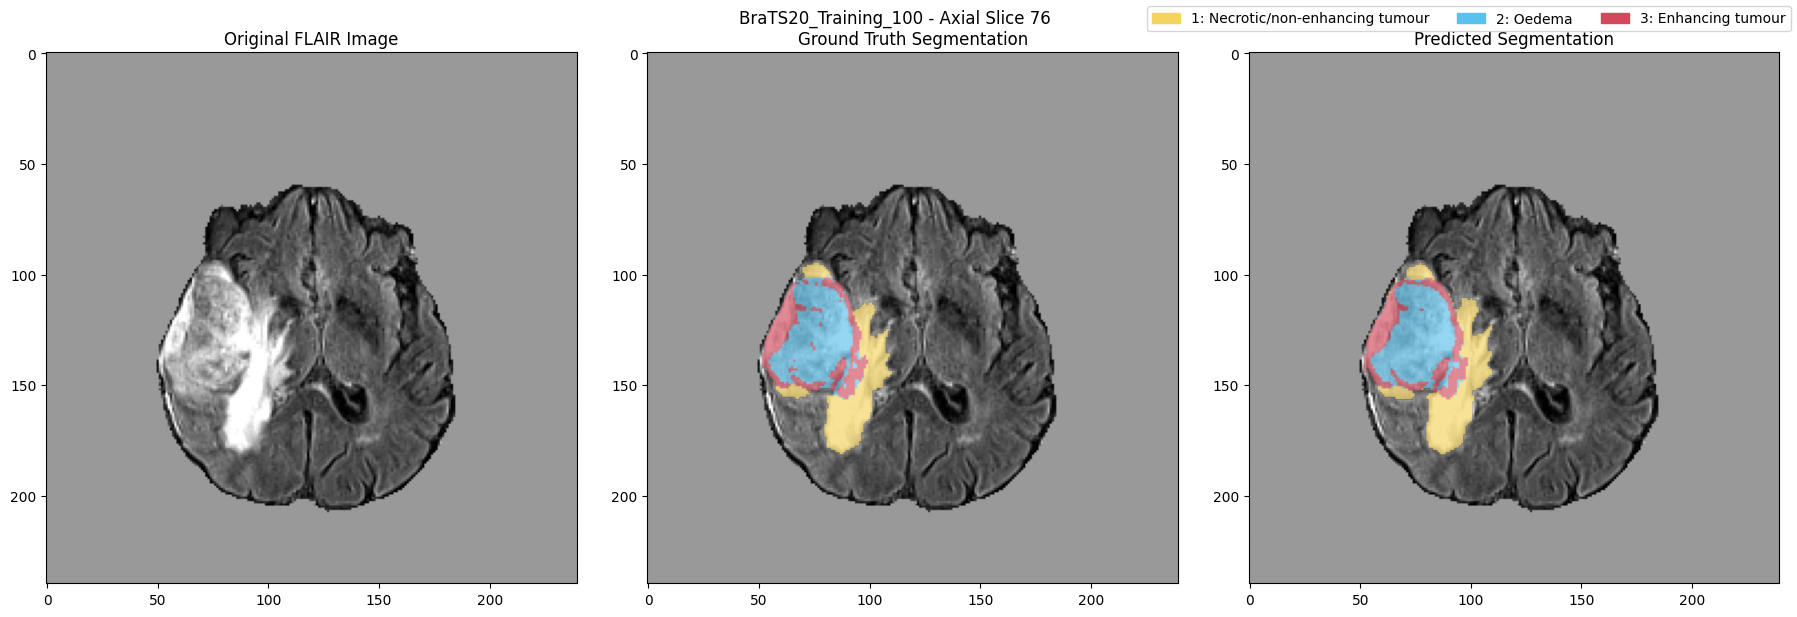

In [ ]:
#
flair_cmap = plt.cm.gray.copy()
flair_cmap.set_bad("#999999")
cmap = ListedColormap(["#f4d35e", "#5bc0eb", "#d1495b"])
figure, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

axes[0].imshow(flair_slice, cmap=flair_cmap, vmin=20, vmax=400)
axes[0].set_title("Original FLAIR Image")

axes[1].imshow(flair_slice, cmap=flair_cmap, vmin=20, vmax=400)
axes[1].imshow(ground_truth_slice, cmap=cmap, vmin=1, vmax=3, alpha=0.65)
axes[1].set_title("Ground Truth Segmentation")

axes[2].imshow(flair_slice, cmap=flair_cmap, vmin=20, vmax=400)
axes[2].imshow(prediction_slice, cmap=cmap, vmin=1, vmax=3, alpha=0.65)
axes[2].set_title("Predicted Segmentation")

figure.suptitle(f"{case} - Axial Slice {slice_index}")
figure.legend(
    handles=[
        Patch(color="#f4d35e", label="1: Necrotic/non-enhancing tumour"),
        Patch(color="#5bc0eb", label="2: Oedema"),
        Patch(color="#d1495b", label="3: Enhancing tumour"),],
    loc="upper right",
    ncol=3,
)
plt.show()

## Summary

This notebook demonstrates a complete nnU-Net v2 training pipeline for BraTS2020, including:
- Dataset preparation  
- Label conversion  
- Preprocessing  
- Training  
- Prediction  
- Evaluation  
- Visualisation  
